# Memahami Karakteristik Data (Data Understanding)

Dalam Data Mining, memahami karakteristik data atau **Statistik Deskriptif** adalah langkah awal yang krusial. Tujuannya adalah untuk mendapatkan gambaran umum tentang distribusi dan sebaran data yang kita miliki.

---

## 1. Ukuran Pemusatan (Central Tendency)

### **A. Mean (Rata-rata)**
Mean adalah nilai rata-rata dari seluruh data. Nilai ini sangat dipengaruhi oleh nilai ekstrem (*outlier*).

$$\bar{x} = \frac{\sum_{i=1}^{n} x_i}{n}$$

**Keterangan:**
* $\bar{x}$ : Rata-rata (*mean*)
* $x_i$ : Nilai data ke-$i$
* $n$ : Jumlah data

### **B. Median (Nilai Tengah)**
Median adalah nilai tengah dari sekumpulan data yang telah diurutkan.

* **Untuk data ganjil:**
$$Me = x_{\frac{n+1}{2}}$$

* **Untuk data genap:**
$$Me = \frac{x_{\frac{n}{2}} + x_{\frac{n}{2} + 1}}{2}$$

### **C. Modus (Mode)**
Modus adalah nilai yang paling sering muncul dalam suatu kumpulan data.

---

## 2. Ukuran Penyebaran (Dispersion)

### **A. Range (Rentang)**
Selisih antara nilai maksimum dan nilai minimum dalam dataset.

$$Range = x_{max} - x_{min}$$

### **B. Standar Deviasi (Simpangan Baku)**
Menggambarkan seberapa besar penyimpangan data dari nilai rata-ratanya.

$$s = \sqrt{\frac{\sum_{i=1}^{n} (x_i - \bar{x})^2}{n-1}}$$

**Keterangan:**
* $s$ : Standar deviasi
* $x_i$ : Nilai data ke-$i$
* $\bar{x}$ : Rata-rata (*mean*)
* $n$ : Jumlah data

## 3. Eksplorasi Dataset Iris

Dataset ini memiliki karakteristik sebagai berikut:
* **Jumlah Data:** 150 data (ID 1 - 150).
* **Komposisi Kelas:** Terdapat 3 jenis spesies (*Setosa, Versicolor, Virginica*), masing-masing berjumlah **50 data**.
* **Fitur Utama:** Memiliki 4 fitur numerik: `sepal_length`, `sepal_width`, `petal_length`, dan `petal_width`.

### **Analisis Kualitas Data**
1. **Missing Values:** Berdasarkan pengecekan, dataset ini memiliki **0 missing values**. Seluruh kolom terisi lengkap.
2. **Outliers (Pencilan):** Identifikasi dilakukan dengan visualisasi Boxplot untuk melihat data yang menyimpang jauh dari rata-rata.

---

Statistik Deskriptif Tiap Spesies:


species             Iris-setosa  Iris-versicolor  Iris-virginica
sepal_length count    50.000000        50.000000       50.000000
             mean      5.006000         5.936000        6.588000
             std       0.352490         0.516171        0.635880
             min       4.300000         4.900000        4.900000
             25%       4.800000         5.600000        6.225000
             50%       5.000000         5.900000        6.500000
             75%       5.200000         6.300000        6.900000
             max       5.800000         7.000000        7.900000
sepal_width  count    50.000000        50.000000       50.000000
             mean      3.418000         2.770000        2.974000
             std       0.381024         0.313798        0.322497
             min       2.300000         2.000000        2.200000
             25%       3.125000         2.525000        2.800000
             50%       3.400000         2.800000        3.000000
             75%       3.675000         3.000000        3.175000
             max       4.400000         3.400000        3.800000
petal_length count    50.000000        50.000000       50.000000
             mean      1.464000         4.260000        5.552000
             std       0.173511         0.469911        0.551895
             min       1.000000         3.000000        4.500000
             25%       1.400000         4.000000        5.100000
             50%       1.500000         4.350000        5.550000
             75%       1.575000         4.600000        5.875000
             max       1.900000         5.100000        6.900000
petal_width  count    50.000000        50.000000       50.000000
             mean      0.244000         1.326000        2.026000
             std       0.107210         0.197753        0.274650
             min       0.100000         1.000000        1.400000
             25%       0.200000         1.200000        1.800000
             50%       0.200000         1.300000        2.000000
             75%       0.300000         1.500000        2.300000
             max       0.600000         1.800000        2.500000

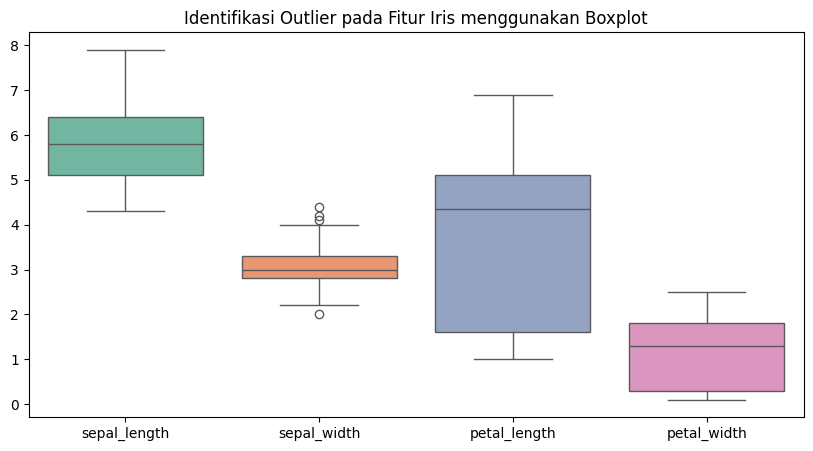

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load Data
df = pd.read_csv('IRIS.csv')

# 2. Statistik Deskriptif per Kelas (Spesies)
print("Statistik Deskriptif Tiap Spesies:")
display(df.groupby('species').describe().T)

# 3. Visualisasi Boxplot
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, palette="Set2")
plt.title("Identifikasi Outlier pada Fitur Iris menggunakan Boxplot")
plt.show()

## 4. Mengukur Jarak (Distance Measurement)

Mengukur jarak digunakan untuk mengetahui seberapa mirip (*similarity*) antara dua objek data.

### **A. Formula Jarak Numerik**

1. **Manhattan Distance ($L_1$):**
$$d(x,y) = \sum_{i=1}^{n} |x_i - y_i|$$
**Keterangan:** Menjumlahkan selisih absolut dari setiap fitur.

2. **Euclidean Distance ($L_2$):**
$$d(x,y) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}$$
**Keterangan:** Jarak garis lurus antar dua titik menggunakan pangkat 2.

3. **Supremum Distance ($L_\infty$):**
$$d(x,y) = \max_i |x_i - y_i|$$
**Keterangan:** Mengambil nilai selisih absolut terbesar di antara semua fitur.

### **B. Implementasi Distance Matrix**
Matriks jarak memungkinkan kita melihat jarak antar objek secara sekaligus, seperti pada aplikasi Orange.

In [14]:
from scipy.spatial import distance
from scipy.spatial import distance_matrix

# Ambil data ID 1 dan ID 2
id1 = df.iloc[0, :4].values
id2 = df.iloc[1, :4].values

print(f"Hasil Jarak Manhattan : {distance.cityblock(id1, id2):.4f}")
print(f"Hasil Jarak Euclidean : {distance.euclidean(id1, id2):.4f}")
print(f"Hasil Jarak Supremum  : {distance.chebyshev(id1, id2):.4f}")

# Distance Matrix untuk 5 data pertama
print("\nDistance Matrix (5 Data Pertama):")
dist_mat = pd.DataFrame(distance_matrix(df.iloc[:5, :4], df.iloc[:5, :4]))
dist_mat.index = dist_mat.columns = [f"ID {i+1}" for i in range(5)]
display(dist_mat)

Hasil Jarak Manhattan : 0.7000
Hasil Jarak Euclidean : 0.5385
Hasil Jarak Supremum  : 0.5000

Distance Matrix (5 Data Pertama):


,ID 1,ID 2,ID 3,ID 4,ID 5
ID 1,0.000000,0.538516,0.509902,0.648074,0.141421
ID 2,0.538516,0.000000,0.300000,0.331662,0.608276
ID 3,0.509902,0.300000,0.000000,0.244949,0.509902
ID 4,0.648074,0.331662,0.244949,0.000000,0.648074
ID 5,0.141421,0.608276,0.509902,0.648074,0.000000


## 5. Tipe Data Campuran & Integrasi Data

### **A. Pengukuran Jarak Data Campuran (Gower Distance)**
Untuk dataset yang memiliki atribut campuran (Numerik, Kategorikal, dan Biner), kita menggunakan konsep **Gower Distance**. Skor perbedaan ($s_{ij}$) dihitung berdasarkan aturan berikut:

1. **Atribut Nominal / Kategorikal:**
   $$s_{ij} = \begin{cases} 0, & \text{jika } x_i = x_j \\ 1, & \text{jika } x_i \neq x_j \end{cases}$$
   *Keterangan: Jarak bernilai 0 jika kategori sama, dan 1 jika kategori berbeda.*

2. **Atribut Numerik:**
   $$s_{ij} = \frac{|x_i - x_j|}{max - min}$$
   *Keterangan: Selisih absolut dibagi dengan rentang (range) nilai pada atribut tersebut.*

3. **Atribut Biner:**
   Dihitung berdasarkan kesamaan atribut (Ya/Tidak) dengan logika yang sama seperti atribut nominal.

### **B. Integrasi Sumber Data**
Data dalam eksplorasi ini ditarik dan diintegrasikan dari berbagai sumber untuk memastikan kelengkapan informasi:

* **Relational Database:** Menggunakan library `SQLAlchemy` untuk melakukan koneksi dan pengambilan data dari **PostgreSQL** dan **MySQL**.
* **File Eksternal:** Pengolahan data yang tersimpan dalam format **CSV** dan **JSON**.
* **Web Statis:** Penguatan metadata melalui referensi web untuk memperkaya konteks analisis data.